**Jaringan Penerbangan Domestik Antar Bandara Internasional**

**TEORI LCC**

https://arxiv.org/html/2509.23670v1

https://wartaardhia.com/index.php/wartaardhia/article/view/445/pdf

**Penelitian Robustness Indonesia**
https://www.researchgate.net/profile/Andry-Alamsyah/publication/335866474_Air_Transportation_Network_Robustness_under_Random_and_Hub-Based_Disruptions/links/62692a87bca601538b6d2697/Air-Transportation-Network-Robustness-under-Random-and-Hub-Based-Disruptions.pdf

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install cartopy airportsdata
import networkx as nx
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import airportsdata
import numpy as np
from copy import deepcopy
from typing import List
from tabulate import tabulate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.4/914.4 kB 18.7 MB/s eta 0:00:00


In [ ]:

url = "https://raw.githubusercontent.com/ulfadwyh002/Data-Skripsi-Airport-Dataset/main/DATA_3_BOBOT%20(1).xlsx"
data = pd.read_excel(url)

data

,IATA_Origin,IATA_Destination,Airline_Code,Origin_Airport_Name,Origin_City,Origin_Province,Destination_Airport_Name,Destination_City,Destination_Province,Route,Weight,Weight_norm
0,BPN,TRK,IU,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Juwata,Kota Tarakan,Kalimantan Utara,BPN - TRK,3,0.974214
1,BPN,TRK,QG,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Juwata,Kota Tarakan,Kalimantan Utara,BPN - TRK,3,0.974214
2,BPN,PNK,ID,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Supadio,Kota Pontianak,Kalimantan Barat,BPN - PNK,5,1.623691
3,BPN,PNK,IU,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Supadio,Kota Pontianak,Kalimantan Barat,BPN - PNK,5,1.623691
4,BPN,PNK,GA,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Supadio,Kota Pontianak,Kalimantan Barat,BPN - PNK,5,1.623691
...,...,...,...,...,...,...,...,...,...,...,...,...
1923,DTB,BTH,IU,Bandar Udara Internasional Sisingamangaraja XII,Kabupaten Tapanuli Utara,Sumatera Utara,Bandar Udara Hang Nadim,Kota Batam,Kepulauan Riau,BTH - DTB,2,0.649476
1924,DTB,LOP,IU,Bandar Udara Internasional Sisingamangaraja XII,Kabupaten Tapanuli Utara,Sumatera Utara,Bandar Udara Zainuddin Abdul Madjid,Kabupaten Lombok Tengah,Nusa Tenggara Barat,DTB - LOP,1,0.324738
1925,DTB,PNK,IU,Bandar Udara Internasional Sisingamangaraja XII,Kabupaten Tapanuli Utara,Sumatera Utara,Bandar Udara Supadio,Kota Pontianak,Kalimantan Barat,DTB - PNK,1,0.324738
1926,DTB,BDJ,IU,Bandar Udara Internasional Sisingamangaraja XII,Kabupaten Tapanuli Utara,Sumatera Utara,Bandar Udara Syamsudin Noor,Kota Banjarbaru,Kalimantan Selatan,BDJ - DTB,1,0.324738


# TOPOLOGI JARINGAN

## GRAF

In [ ]:
# Salin data agar data asli tidak berubah
df = data.copy()
# 1. Bangun graf dari dataframe rute penerbangan
G = nx.from_pandas_edgelist(df, "IATA_Origin", "IATA_Destination", edge_attr="Weight_norm", create_using=nx.Graph())

## DISTRIBUSI DERAJAT

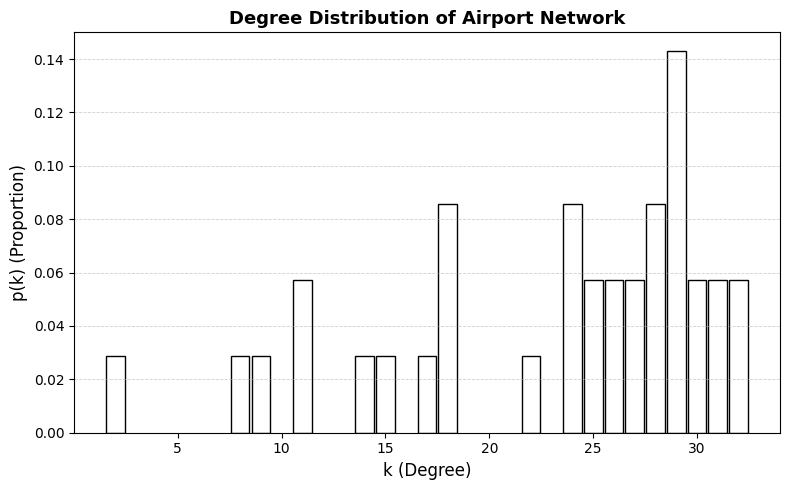

In [ ]:


# Hitung derajat tiap simpul
degree_dict = dict(G.degree())
degrees = list(degree_dict.values())

# Hitung distribusi p(k)
degree_count = pd.Series(degrees).value_counts().sort_index()
pk = degree_count / degree_count.sum()  # proporsi

# --- Visualisasi
plt.figure(figsize=(8,5))
plt.bar(pk.index, pk.values, width=0.9, color="white", edgecolor="black", linewidth=1.0)   # gaya bar

plt.xlabel("k (Degree)", fontsize=12)
plt.ylabel("p(k) (Proportion)", fontsize=12)
plt.title("Degree Distribution of Airport Network", fontsize=13, weight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.6, linewidth=0.6)
plt.tight_layout()
plt.show()


## KESELURUHAN JARINGAN

In [ ]:


# 2. Hitung N awal (jumlah node)
N_initial = len(G)  # Menghitung jumlah node awal (bandara)

# <k>: Rata-rata degree/titik (unweighted)
def average_degree(G):  # Definisi fungsi untuk menghitung rata-rata derajat node (unweighted, tanpa bobot)
    degrees = [d for n, d in G.degree()]  # Mengumpulkan derajat (jumlah koneksi) setiap node
    return np.mean(degrees)  # Mengembalikan rata-rata derajat menggunakan NumPy

# C: Clustering coefficient rata-rata (unweighted)
def average_clustering(G):  # Definisi fungsi untuk menghitung rata-rata koefisien clustering (seberapa saling terhubung tetangga node)
    return np.mean(list(nx.clustering(G).values()))  # Menggunakan NetworkX untuk hitung clustering per node, lalu rata-rata

# Lw: Weighted average shortest path length (cost=1/weight, pada biggest CC saja jika tidak terhubung)
def average_weighted_path_length(G):  # Definisi fungsi untuk rata-rata panjang jalur terpendek berbobot
    if len(G) <= 1: return 0  # Jika graf <=1 node, panjang 0
    H = G.copy()  # Salin graf
    for u, v, data in H.edges(data=True):  # Loop setiap edge untuk set cost
        w = data.get("Weight", 1)  # Ambil Weight
        data["cost"] = 1 / w if w > 0 else 1e9  # Set cost = 1/Weight => semakin besar bobot maka semakin baik
    if not nx.is_connected(H):  # Jika graf tidak terhubung
        largest_cc = max(nx.connected_components(H), key=len)  # Cari komponen terbesar
        H = H.subgraph(largest_cc).copy()  # Buat subgraph hanya komponen terbesar
    return nx.average_shortest_path_length(H, weight="cost")  # Hitung rata-rata panjang jalur terpendek berbobot pada subgraph

def largest_connected_component_ratio(G, N_initial):  # Fungsi untuk rasio ukuran komponen terbesar vs N awal
    if len(G) == 0: return 0  # Jika graf kosong, kembalikan 0 untuk hindari error
    largest_cc = max(nx.connected_components(G), key=len)  # Cari komponen terbesar berdasarkan jumlah node
    return len(largest_cc) / N_initial  # Hitung rasio ukuran komponen terbesar terhadap N awal

def weighted_efficiency(G):  # Fungsi untuk efisiensi global berbobot (rata-rata 1/distance)
    if len(G) <= 1: return 0  # Jika graf kecil, efisiensi 0
    H = G.copy()  # Salin graf untuk modifikasi
    for u, v, data in H.edges(data=True):  # Loop setiap edge untuk ubah bobot menjadi cost
        w = data.get("Weight", 1)  # Ambil bobot Weight
        data["cost"] = 1 / w if w > 0 else 1e9  # Set cost = 1/Weight (kebalikan bobot)
    path_lengths = dict(nx.all_pairs_dijkstra_path_length(H, weight="cost"))  # Hitung panjang jalur terpendek berbobot untuk semua pasangan
    n = len(G)  # Jumlah node
    eff_sum = 0  # Inisialisasi sum efisiensi
    for u in G.nodes():  # Loop node u
        for v in G.nodes():  # Loop node v
            if u != v:  # Hindari pasangan sama
                try:  # Coba ambil distance
                    d = path_lengths[u][v]  # Ambil panjang jalur u-v
                    if d > 0:  # Jika terhubung
                        eff_sum += 1 / d  # Tambahkan 1/d ke sum
                except KeyError:  # Jika tidak terhubung, lewati
                    pass
    return eff_sum / (n * (n - 1))  # Kembalikan rata-rata efisiensi

# Hitung metrik-metrik global jaringan
network_metrics = {
    "<k>": average_degree(G),
    "C": average_clustering(G),
    "Lw": average_weighted_path_length(G),
    "S": largest_connected_component_ratio(G, N_initial),
    "Ew": weighted_efficiency(G)
}

# Export ke DataFrame satu baris
df_metrics = pd.DataFrame([network_metrics])

# Tampilkan
print(df_metrics)



         <k>         C       Lw    S        Ew
0  23.028571  0.849286  1.32605  1.0  0.838095


- **k (Degree)** → Mengukur banyaknya koneksi langsung yang dimiliki suatu bandara.
- **C (Clustering Coefficient)** → Mengukur seberapa rapat tetangga sebuah bandara saling terhubung.
- **S (Size of Largest Component)** → Menunjukkan persentase node yang masih terhubung dalam komponen terbesar setelah sebuah bandara dihapus.
- **Lw (Weighted Average Shortest Path)** → Mengukur jarak rata-rata terpendek antarbandara dengan mempertimbangkan bobot atau jarak rute.
- **Ew (Weighted Global Efficiency)** → Mengukur seberapa efisien jaringan menghubungkan semua bandara satu sama lain, dengan mempertimbangkan jarak atau bobot tiap rute. Semakin mudah dan semakin pendek rute antarbandara ditempuh (dengan bobot jarak/waktu/biaya), semakin tinggi nilai EW. Semakin sulit, jauh, atau memutar rute antarbandara, semakin rendah nilai EW.

:)

* (k = 23,06) menunjukkan bahwa bandara -bandara dalam jaringan ini rata-rata terkoneksi dengan 23 bandara lain.
* (C = 0,861) menunjukkan Rata-rata 86% pasangan tetangga antarbandara juga saling terhubung satu sama lain, ini mengindikasikan bahwa jaringan memiliki keterhubungan yang erat.

* Nilai jarak rata-rata terpendek antarbandara (Lw = 0,468) menunjukkan bahwa konektivitas dalam jaringan sangat efisien. Artinya, bandara-bandara dapat dijangkau melalui jalur yang relatif pendek dan umumnya hanya memerlukan sedikit transit untuk mencapai bandara internasional lainnya.

* Seluruh bandara berada dalam satu komponen utama (S = 1,0). (tidak perlu ada dapat topologi)

* Nilai efisiensi global jaringan (Ew = 2,991) menunjukkan bahwa jaringan penerbangan ini bekerja dengan cukup efisien. Secara rata-rata, jarak efektif antarbandara berada di kisaran tiga rute, sehingga pergerakan dalam jaringan dapat berlangsung dengan cepat

## ROBUSTNESS (NODE REMOVAL)


### Teori

**Single-node removal** → hapus node satu-satu, semua node lain masih ada → lihat seberapa kritis node itu sendirian.

Metode single removal mengukur kontribusi individual tiap simpul terhadap struktur jaringan dengan menghapus satu node tanpa menghilangkan simpul sebelumnya (tidak memperhatikan urutan penghapusan berdasrkan wlec)

Single removal dipakai untuk melihat dampak langsung dari hilangnya satu bandara kunci (misalnya CGK).

 Sebagai baseline untuk membandingkan dampak kegagalan individual terhadap robustness.


**Sequential removal** → Menghapus node satu per satu secara berurutan berdasarkan hasil WLEC.

Tujuannya adalah mensimulasikan proses kerusakan jaringan secara bertahap, khususnya jika simpul-simpul dihapus sesuai urutan tingkat kepentingannya (misalnya berdasarkan WLEC). Karena setiap simpul yang sudah dihapus tidak dikembalikan, metode ini menggambarkan dinamika runtuhnya jaringan, dan penurunan efisiensi drastis.

**tapi sebenrnya saya sudah punya yag namnya weighted laplacian energy centrality untuk cari node kritis, brrti nanti lebih ke di validasi wlec oleh single removal dan di uji hasilnya dengan sequential gtu ya**?

Ada 4 metode operasional:

Random–Single

Random–Sequential

Targeted–Single

Targeted–Sequential

:

**INTERPRETASI MATRIKS K** :
Nilai k merepresentasikan derajat keterhubungan minimum dalam suatu subgraf, yang mencerminkan seberapa "kokoh" jaringan secara struktural. Node yang menjadi kunci keterhubungan memiliki peran yang sangat penting karena menghubungkan banyak bagian jaringan atau memelihara kohesi jaringan secara keseluruhan

*   Jika <k> TURUN → jaringan RUSAK → node tersebut PENTING

Jika penghapusan suatu node menyebabkan penurunan nilai <k>, maka kondisi tersebut menunjukkan bahwa jaringan mengalami degradasi konektivitas; artinya node tersebut merupakan simpul penting (critical node) dari perspektif robust-ness degree.
*   Jika <k> NAIK → jaringan TIDAK RUSAK → node tersebut TIDAK PENTING

Jika penghapusan suatu node tidak menurunkan atau bahkan meningkatkan nilai <k>, maka jaringan tetap stabil dan node tersebut tidak memiliki peran esensial dalam mempertahankan tingkat keterhubungan jaringan.




:

**INTERPRETASI MATRIKS C** adalah "tingkat kepadatan komunitas” dalam jaringan atau mengukur seberapa besar tetangga dari suatu simpul saling terhubung satu sama lain.

Clustering coefficient (C) menggambarkan sejauh mana tetangga suatu simpul saling terhubung satu sama lain. Nilai C yang tinggi menunjukkan adanya struktur komunitas yang kuat, di mana simpul-simpul memiliki konektivitas lokal yang rapat. Dalam konteks robustness, penurunan nilai C setelah penghapusan simpul menandakan bahwa simpul tersebut berperan penting dalam menjaga kerapatan komunitas jaringan. Sebaliknya, jika nilai C stabil atau meningkat, simpul tersebut tidak memiliki kontribusi signifikan terhadap struktur komunitas.

**Jika penghapusan suatu node menyebabkan penurunan nilai clustering coefficient (C) global, hal ini menunjukkan bahwa node tersebut sebelumnya berperan dalam menghubungkan tetangganya, menjadi jembatan antar rute lokal, dan memperkuat struktur komunitas di wilayah tertentu.**



:

S (Size of Largest Connected Component) menunjukkan ukuran komponen terbesar dalam jaringan setelah penghapusan suatu node. Komponen terbesar ini merepresentasikan jumlah simpul yang masih saling terhubung dalam satu subgraf terbesar. Dengan demikian, nilai S menjadi indikator penting untuk menilai robustness global jaringan, yaitu kemampuan jaringan untuk tetap utuh atau mulai terfragmentasi ketika simpul-simpul kritis dihapus.

**Kenapa nilai S sama di tiap proses penghapusan ?** karena S terlihat “tidak sensitif” terhadap penghapusan node penting / S tidak berkatan dengan apakah node itu penting, S hanya bekerja pada ukuran komponen terbesar.

**Lalu apa fungsinya S di robustness yaaaaaaaaaaaaaa???:(**

:)

**Weighted Laplacian Energy (Ew)** mengukur energi spektral dari matriks Laplacian berbobot jaringan dan merepresentasikan stabilitas serta kekuatan jaringan secara global, bukan hanya derajat atau kerapatan lokal. Ew menunjukkan seberapa kuat keterhubungan antar node dengan memperhitungkan bobot, yang dapat berupa jumlah rute, frekuensi penerbangan, atau kapasitas rute antar bandara. Semakin besar perubahan Ew setelah penghapusan suatu node, semakin besar dampak node tersebut terhadap jaringan. Penurunan Ew menandakan bahwa jaringan menjadi kurang stabil karena distribusi bobot dan koneksi terganggu, sehingga node yang menyebabkan penurunan drastis dapat dikategorikan sebagai simpul kritis untuk menjaga kestabilan jaringan secara keseluruhan.



:)

**Weighted Average Shortest Path (Lw)** mengukur rata-rata jarak terpendek berbobot antar semua pasangan node dalam jaringan, yang merepresentasikan efisiensi global jaringan. Jika penghapusan suatu node menyebabkan Lw meningkat, hal ini menunjukkan bahwa jaringan menjadi kurang efisien, karena rute antar node menjadi lebih panjang atau kompleks, sehingga node tersebut dianggap penting untuk menjaga efisiensi jaringan secara global. Sebaliknya, jika Lw tetap atau menurun setelah penghapusan node, jaringan masih mempertahankan efisiensi, sehingga node tersebut kurang berpengaruh terhadap operasi jaringan secara keseluruhan.

:

Eigenvector centrality (A) lebih "lokal", lebih banyak dipengaruhi degree dan koneksi tetangga inti.

Laplacian centrality (L) lebih "global", mengukur efek node terhadap seluruh jaringan.

k = 0 → Semua node yang tersisa tidak memiliki koneksi (degree = 0).

C = 0 → Tidak ada lagi klaster lokal, karena tidak ada tetangga yang bisa membentuk klaster.

S ≈ 0.029 → Ukuran largest component sangat kecil (hanya beberapa node tersisa yang terisolasi).

Ew = 0 → Efisiensi global = 0 → jaringan tidak mampu lagi menyebarkan “pergerakan” antar node.

Lw = 0 → Jarak rata-rata terpendek = 0 → karena tidak ada jalur yang tersisa.

### SINGLE NODE REMOVAL


*  Metode single removal mengukur kontribusi individual tiap simpul terhadap struktur jaringan dengan menghapus satu simpul tanpa menghilangkan simpul sebelumnya (tidak memperhatikan urutan penghapusan berdasrkan wlec)


*   Single removal dipakai untuk menunjukkan peran kritis / kepentingan simpul tersebut secara mandiri yang sejalan dengan temuan dari metode WLEC.



In [ ]:

# Membuat graf tak berarah dari DataFrame df (node: kode IATA bandara, edge: rute, atribut Weight: frekuensi penerbangan)
N_initial = len(G)  # Menyimpan jumlah node awal (bandara) untuk referensi metrik S (rasio komponen terbesar)

# Definisi fungsi metrik (sama seperti sebelumnya, untuk menghitung properti jaringan)
def average_degree(G):  # Fungsi untuk rata-rata derajat node (unweighted)
    return np.mean([d for _, d in G.degree()])  # Hitung rata-rata derajat semua node

def average_clustering(G): # Fungsi untuk rata-rata koefisien clustering (unweighted)
    Ci = nx.clustering(G)   # sudah pakai C_i = 2E_i / (k_i (k_i-1))
    return np.mean(list(Ci.values()))

def largest_connected_component_ratio(G, N_initial):  # Fungsi untuk rasio ukuran komponen terbesar vs N awal
    if len(G) == 0: return 0  # Jika graf kosong, kembalikan 0 untuk hindari error
    largest_cc = max(nx.connected_components(G), key=len)  # Cari komponen terbesar berdasarkan jumlah node
    return len(largest_cc) / N_initial  # Hitung rasio ukuran komponen terbesar terhadap N awal

def weighted_efficiency(G):  # Fungsi untuk efisiensi global berbobot (rata-rata 1/distance)
    if len(G) <= 1: return 0  # Jika graf kecil, efisiensi 0
    H = G.copy()  # Salin graf untuk modifikasi
    for u, v, data in H.edges(data=True):  # Loop setiap edge untuk ubah bobot menjadi cost
        w = data.get("Weight_norm", 1)  # Ambil bobot Weight
        data["cost"] = 1 / w if w > 0 else 1e9  # Set cost = 1/Weight (kebalikan bobot)
    path_lengths = dict(nx.all_pairs_dijkstra_path_length(H, weight="cost"))  # Hitung panjang jalur terpendek berbobot untuk semua pasangan
    n = len(G)  # Jumlah node
    eff_sum = 0  # Inisialisasi sum efisiensi
    for u in G.nodes():  # Loop node u
        for v in G.nodes():  # Loop node v
            if u != v:  # Hindari pasangan sama
                try:  # Coba ambil distance
                    d = path_lengths[u][v]  # Ambil panjang jalur u-v
                    if d > 0:  # Jika terhubung
                        eff_sum += 1 / d  # Tambahkan 1/d ke sum
                except KeyError:  # Jika tidak terhubung, lewati
                    pass
    return eff_sum / (n * (n - 1))  # Kembalikan rata-rata efisiensi

def average_weighted_path_length(G):  # Fungsi untuk rata-rata panjang jalur terpendek berbobot
    if len(G) <= 1: return 0  # Jika graf kecil, panjang 0
    H = G.copy()  # Salin graf
    for u, v, data in H.edges(data=True):  # Loop edge untuk set cost
        w = data.get("Weight_norm", 1)  # Ambil Weight
        data["cost"] = 1 / w if w > 0 else 1e9  # Set cost = 1/Weight
    if not nx.is_connected(H):  # Jika tidak terhubung
        largest_cc = max(nx.connected_components(H), key=len)  # Cari komponen terbesar
        H = H.subgraph(largest_cc).copy()  # Buat subgraph komponen terbesar
    return nx.average_shortest_path_length(H, weight="cost")  # Hitung rata-rata panjang jalur berbobot

# Simulasi penghapusan node satu per satu
results = []  # Inisialisasi list untuk menyimpan hasil simulasi setiap penghapusan node
for node in G.nodes():  # Loop setiap node (bandara) dalam graf asli
    G_temp = G.copy()  # Salin graf asli untuk simulasi (agar tidak mengubah asli)
    G_temp.remove_node(node)  # Hapus node tersebut dari salinan graf
    metrics = {  # Hitung metrik untuk graf setelah penghapusan
        "Removed_Node": node,  # Simpan nama node yang dihapus
        "<k>": average_degree(G_temp),  # Hitung <k> setelah penghapusan
        "C": average_clustering(G_temp),  # Hitung C setelah penghapusan
        "S": largest_connected_component_ratio(G_temp, N_initial),  # Hitung S setelah penghapusan
        "Ew": weighted_efficiency(G_temp),  # Hitung Ew setelah penghapusan
        "Lw": average_weighted_path_length(G_temp)  # Hitung Lw setelah penghapusan
    }
    results.append(metrics)  # Tambahkan hasil metrik ke list results

# Buat DataFrame hasil
df_results = pd.DataFrame(results)  # Konversi list results menjadi DataFrame Pandas untuk analisis mudah

# Hitung skor penurunan rata-rata dari baseline (jaringan penuh)
baseline = {  # Hitung metrik baseline dari graf penuh (sebelum penghapusan)
    "<k>": average_degree(G),  # <k> baseline
    "C": average_clustering(G),  # C baseline
    "S": largest_connected_component_ratio(G, N_initial),  # S baseline
    "Ew": weighted_efficiency(G),  # Ew baseline
    "Lw": average_weighted_path_length(G)  # Lw baseline
}

# Perhitungan dampak penghapusan node
def metric_change(val, metric):  # Fungsi untuk hitung perubahan metrik dari baseline
    if metric == "Lw":  # Untuk Lw, peningkatan (val > baseline) dianggap buruk, jadi kembalikan val - baseline (positif jika memburuk)
        return val - baseline[metric]  # Hitung selisih (peningkatan Lw = dampak negatif)
    else:  # Untuk metrik lain (<k>, C, S, Ew), penurunan (baseline - val) dianggap buruk
        return baseline[metric] - val  # Hitung selisih (penurunan = dampak negatif)

df_results["Impact_Score"] = df_results.apply(  # Tambahkan kolom Impact_Score ke DataFrame
    lambda row: sum(metric_change(row[m], m) for m in ["<k>", "C", "S", "Ew"]) - metric_change(row["Lw"], "Lw"),  # Hitung skor sebagai sum penurunan metrik positif dikurangi peningkatan Lw (semakin tinggi skor, semakin besar dampak negatif penghapusan)
    axis=1  # Terapkan per baris
)

# Urutkan descending berdasarkan Impact_Score
df_results = df_results.sort_values(by="Impact_Score", ascending=False)  # Urutkan DataFrame berdasarkan Impact_Score menurun (node dengan dampak terbesar di atas)

print(df_results[['Removed_Node', "<k>", "C", "S", "Ew", "Lw", "Impact_Score"]])  # Cetak DataFrame dengan kolom utama (nama node yang dihapus, metrik, dan skor dampak) untuk output


   Removed_Node        <k>         C         S        Ew        Lw  \
0           BPN  21.823529  0.843488  0.971429  0.918098  1.517454   
9           CGK  21.823529  0.842834  0.971429  0.862496  1.590952   
13          DPS  21.882353  0.840364  0.971429  0.924061  1.495802   
5           KNO  21.882353  0.844080  0.971429  0.914769  1.507133   
8           BTH  21.941176  0.844161  0.971429  0.942194  1.484419   
12          SUB  21.941176  0.848619  0.971429  0.931427  1.493942   
7           PKU  22.000000  0.844456  0.971429  0.926734  1.491226   
18          PLM  22.000000  0.843752  0.971429  0.935934  1.487390   
14          LOP  22.000000  0.843294  0.971429  0.941082  1.483463   
15          UPG  22.000000  0.844699  0.971429  0.930743  1.492912   
21          TKG  22.000000  0.843330  0.971429  0.952883  1.473221   
16          MDC  22.058824  0.816135  0.971429  0.943656  1.484497   
6           PDG  22.058824  0.818128  0.971429  0.935439  1.493345   
11          YIA  22.

#### VISUALISASI SINGGLE REMOVAL NODE

In [ ]:
import matplotlib.pyplot as plt

# Pastikan urutan berdasarkan dampak terbesar
df_plot = df_results.copy()

# Label node sesuai urutan dampak
x_labels = df_plot["Removed_Node"]
x_pos = np.arange(len(x_labels))


In [ ]:
df_viz = df_results.copy()

# Hitung perubahan relatif terhadap baseline
df_viz["Δk"]  = baseline["<k>"] - df_viz["<k>"]
df_viz["ΔC"]  = baseline["C"]  - df_viz["C"]
df_viz["ΔS"]  = baseline["S"]  - df_viz["S"]
df_viz["ΔEw"] = baseline["Ew"] - df_viz["Ew"]
df_viz["ΔLw"] = df_viz["Lw"] - baseline["Lw"]   # Lw: naik = buruk


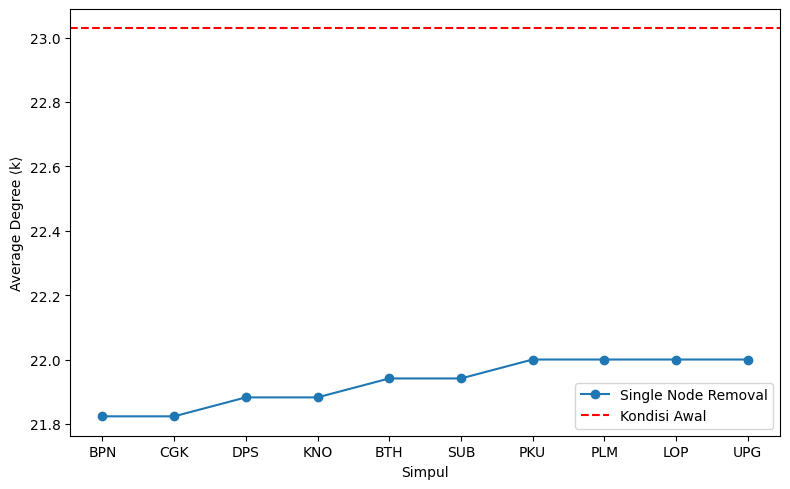

In [ ]:
top10_k = df_viz.sort_values("Δk", ascending=False).head(10)

x = range(1, 11)

plt.figure(figsize=(8,5))
plt.plot(x, top10_k["<k>"], marker='o', label="Single Node Removal")
plt.axhline(baseline["<k>"], color='red', linestyle='--', label="Kondisi Awal")
plt.xticks(x, top10_k["Removed_Node"])
plt.ylabel("Average Degree ⟨k⟩")
plt.xlabel("Simpul")
plt.legend()
plt.tight_layout()
plt.show()


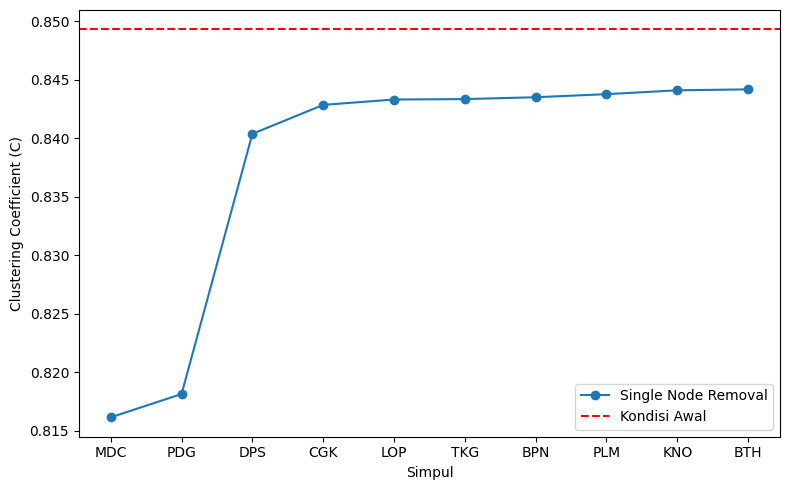

In [ ]:
top10_C = df_viz.sort_values("ΔC", ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.plot(x, top10_C["C"], marker='o', label="Single Node Removal")
plt.axhline(baseline["C"], color='red', linestyle='--', label="Kondisi Awal")

plt.xticks(x, top10_C["Removed_Node"])
plt.ylabel("Clustering Coefficient (C)")
plt.xlabel("Simpul")
plt.legend()
plt.tight_layout()
plt.show()


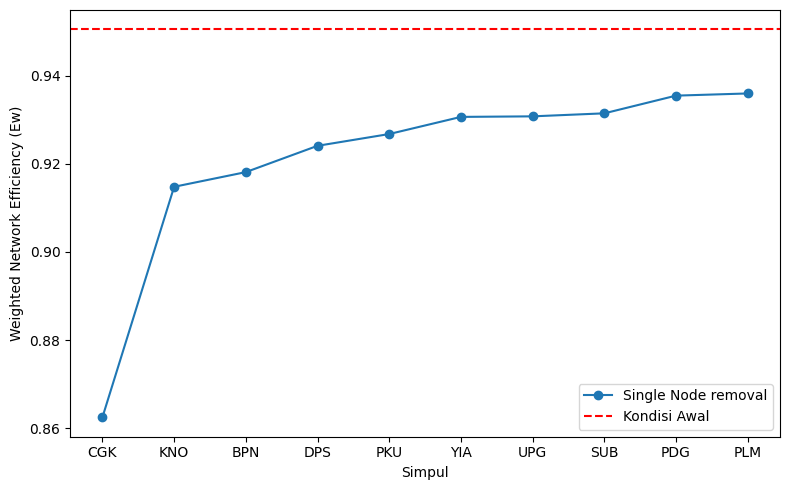

In [ ]:
top10_Ew = df_viz.sort_values("ΔEw", ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.plot(x, top10_Ew["Ew"], marker='o', label="Single Node removal")
plt.axhline(baseline["Ew"], color='red', linestyle='--', label="Kondisi Awal")

plt.xticks(x, top10_Ew["Removed_Node"])
plt.ylabel("Weighted Network Efficiency (Ew)")
plt.xlabel("Simpul")
plt.legend()
plt.tight_layout()
plt.show()


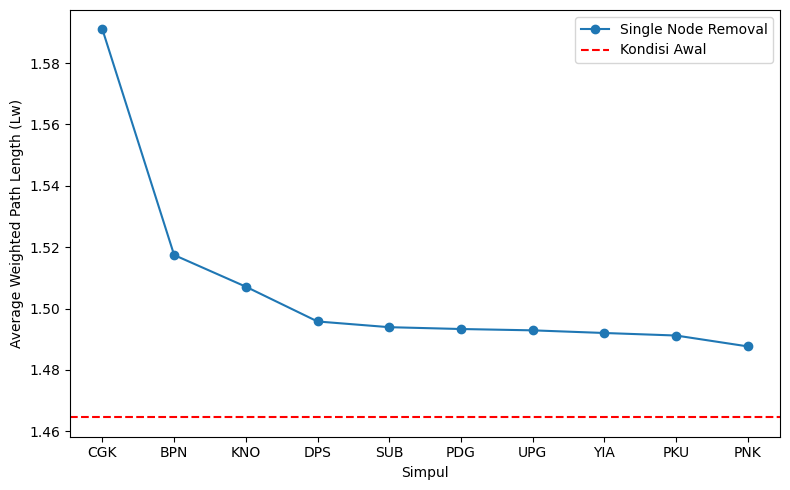

In [ ]:
top10_Lw = df_viz.sort_values("ΔLw", ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.plot(x, top10_Lw["Lw"], marker='o', label="Single Node Removal")
plt.axhline(baseline["Lw"], color='red', linestyle='--', label="Kondisi Awal")

plt.xticks(x, top10_Lw["Removed_Node"])
plt.ylabel("Average Weighted Path Length (Lw)")
plt.xlabel("Simpul")
plt.legend()
plt.tight_layout()
plt.show()


## Total Impact

In [ ]:
# Baseline
baseline = {
    "<k>": average_degree(G),
    "C": average_clustering(G),
    "Ew": weighted_efficiency(G),
    "Lw": average_weighted_path_length(G)
}

def metric_change(val, metric):
    if metric == "Lw":
        return val - baseline[metric]
    else:
        return baseline[metric] - val

df_results["Impact_Score"] = df_results.apply(
    lambda row: (
        metric_change(row["<k>"], "<k>") +
        metric_change(row["C"], "C") +
        metric_change(row["Ew"], "Ew") -
        metric_change(row["Lw"], "Lw")
    ),
    axis=1
)


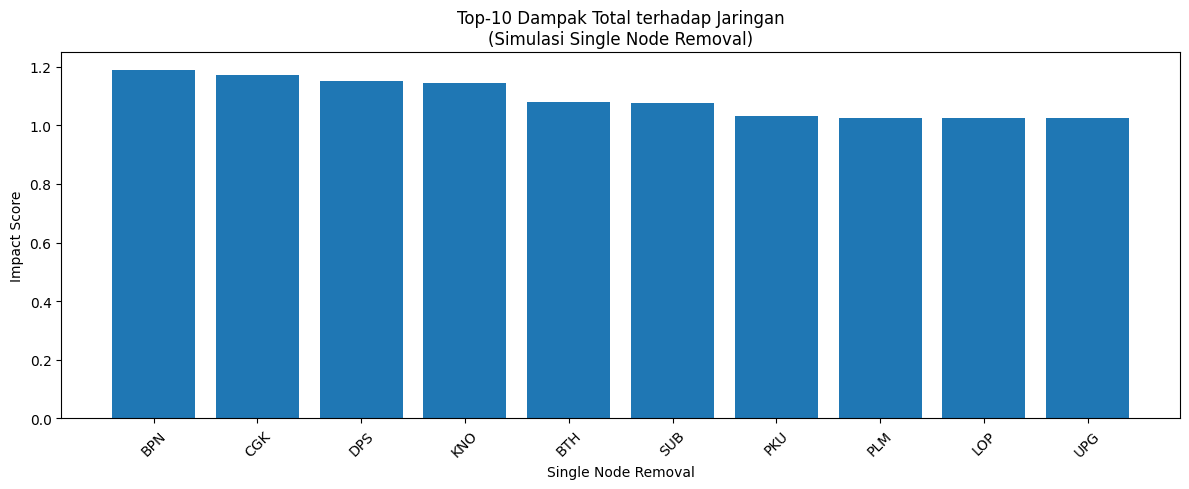

In [ ]:
# Ambil Top-10 node dengan dampak terbesar
top10_impact = df_results.head(10)

x_pos = np.arange(len(top10_impact))
x_labels = top10_impact["Removed_Node"]

plt.figure(figsize=(12,5))
plt.bar(x_pos, top10_impact["Impact_Score"])

plt.xticks(x_pos, x_labels, rotation=45)
plt.ylabel("Impact Score")
plt.xlabel("Single Node Removal")
plt.title("Top-10 Dampak Total terhadap Jaringan\n(Simulasi Single Node Removal)")

plt.tight_layout()
plt.show()


## Khusus CGK

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Salin graf awal
G_initial = G.copy()

# Buat graf setelah CGK dihapus
G_removed = G.copy()
G_removed.remove_node("CGK")

# Layout disimpan dari graf awal (agar konsisten)
pos = nx.spring_layout(G_initial, seed=42)


In [ ]:
def get_component_colors(G):
    components = list(nx.connected_components(G))
    color_map = {}
    for i, comp in enumerate(components):
        for node in comp:
            color_map[node] = i
    return color_map, len(components)


In [ ]:
colors_init, n_comp_init = get_component_colors(G_initial)
colors_removed, n_comp_removed = get_component_colors(G_removed)


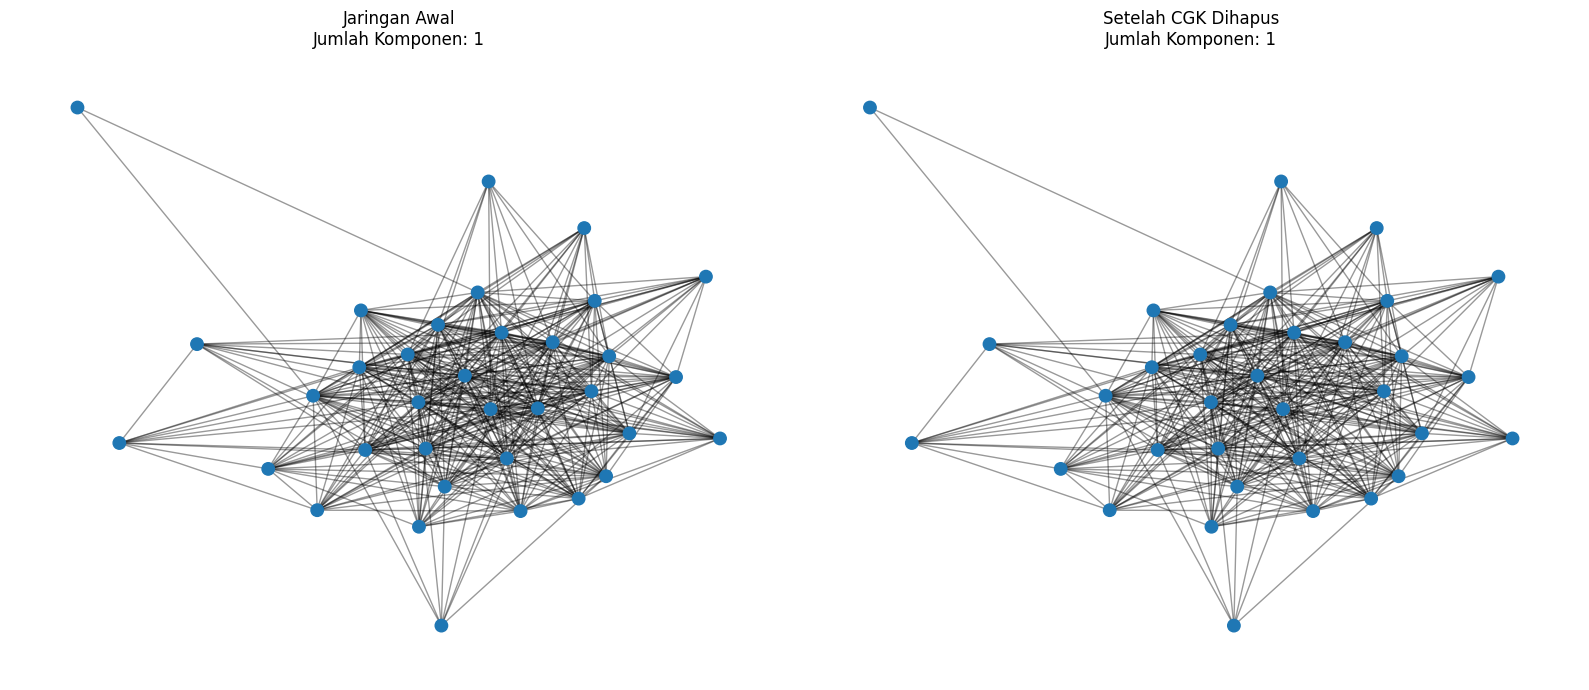

In [ ]:
plt.figure(figsize=(16,7))

# =====================
# JARINGAN AWAL
# =====================
plt.subplot(1, 2, 1)
nx.draw_networkx_edges(G_initial, pos, alpha=0.4)
nx.draw_networkx_nodes(
    G_initial,
    pos,
    node_size=80,
    node_color=[colors_init[n] for n in G_initial.nodes()],
    cmap=plt.cm.tab20
)
plt.title(f"Jaringan Awal\nJumlah Komponen: {n_comp_init}")
plt.axis("off")

# =====================
# SETELAH CGK DIHAPUS
# =====================
plt.subplot(1, 2, 2)
nx.draw_networkx_edges(G_removed, pos, alpha=0.4)
nx.draw_networkx_nodes(
    G_removed,
    pos,
    node_size=80,
    node_color=[colors_removed[n] for n in G_removed.nodes()],
    cmap=plt.cm.tab20
)
plt.title(f"Setelah CGK Dihapus\nJumlah Komponen: {n_comp_removed}")
plt.axis("off")

plt.tight_layout()
plt.show()


### Interpretasi jarigan domistik internasional indonesia

**Interpretasi**



*   Average Degree (k)
Node yang paling menurun ketika dihapus adalah CGK, KNO, BPN, DPS, PKU, yang manandakan bahwa node tersebut adalah hub dengan konektivitas tinggi, menghapus node tersebut dapat membuat banyak koneksi hilang, struktur jaringan melemah.

*   Clustering Coefficient (C)
Node yang paling membuat menurun adalah PDG (penurunann terbesar) dan MDC diikuti oleh PDG, CGK, dan LOP dan PKU . Node tersebut berarti penting dalam menjaa clustering lokal atau penjaga struktur komunitas lokal, walaupun bukan hub besar tetapi penjadi **penghubung lokal** .

*   Largest Connected Component Ratio (S)
bagian ini tidak ada penurunan sama sekali yang berarti tidak ada node yang menyebabkan jaringan pecah menjadi beberapa komponen. **Meskipun hub utama dihapus, jaringan masih memiliki jalur alternatif yang cukup, menunjukkan tingkat robust yang tinggi** S akan benar benar turun jika node itu adalah articulation point (titik yang memutus jaringan)

*   Weighted Global Efficiency (Ew)
penurnan paling besar adalaah node CGK (paling signifikan), KNO, BPN, ketika Ew menurun maka efisiensi global jaringan memburuk ynag berrati banyak rute yang lebih panjang untuk dulalui, kemampuan peyebaran informasi atau mobilitas menurun karena hub besar hilang yaitu CGK (hub efisiensi nasional ).

*   Weighted Average Shortest Path Length (Lw) , berbeda dengan 4 matriks diatas, matrik ini adalah kenaikan dianggap buruk. Kenaikan terbesar adalah ketika node CGK, KNO, BPN, DPS, PKU. ketika CGK dihapus maka rata rata jalur terpendek meningkat tajam yang berarti rute mulai tidak efisien, karena node node tersebut adalah jalur tercepat mempersingkat pemindahan antar bandara. Maka CGK adalah paling kritis. **Kenapa kenaikan lw dianggap buruk?**
karena lw adalaah rata rata shortest path jika path menjadi lebih panjang atau naik maka ini adalah buruk



*   kesimpulan
1. CGK merupakan hub nasional yang merusak paling besar pada matriks K, Ew, dan Lw dan menjadi dampak terbesar pad struktur jaringan
2. KNO merupakan hub utama di sumatera, hilangnya bandara ini sangar menurunkan efisiensi global dan Lw
3. BPN merupakan hub utama di kalimantan dan mempengaruhi distribusi derajat, efisiensi dan jalur terpendek.

dan menariknya, jaringan tetap tidak terfragmentasi pada setiap skenario penghapusan node (S tetap = 1), mengindikasikan tingkat redundansi jalur yang tinggi dan robust secara global.





**POIN KEANEHAN** : kenapa bandara KJT (kerjati, Majalengka, Jawa Barat) rute nya sangat sedikit banhkan paling sedkit padahal bandar atersebut adalah bandara terbesar ke 2 di indonesia.

BISA KAH DIMASUKKAN DALAM PENJELASAN : Meskipun Kertajati merupakan bandara terbesar kedua di Indonesia dari sisi luas area, hasil analisis centrality menunjukkan bahwa KJT memiliki nilai centrality sangat rendah. Hal ini mengindikasikan bahwa ukuran fisik bandara tidak berbanding lurus dengan perannya dalam struktur jaringan. Rendahnya degree, betweenness, dan WLEC KJT disebabkan oleh terbatasnya jumlah rute yang beroperasi serta belum optimalnya fungsi KJT sebagai hub regional.

### SEQUENTIAL NODE REMOVAL

In [ ]:
# ============================
#  WLEC A
# ============================

# 1. Daftar node urut berdasarkan WLEC
wlec_a = ["CGK", "BPN", "DPS", "KNO", "BTH", "SUB", "LOP", "TKG", "PKU", "PLM",
          "UPG", "MDC", "PDG", "YIA", "BDJ", "KOE", "PNK", "SRG", "DJJ", "BTJ",
          "SOQ", "AMQ", "SOC", "TJQ", "TRK", "LBJ", "TNJ", "AAP", "BIK", "PLW",
          "DTB", "HLP", "MKQ", "BWX", "KJT"]

N_initial = len(G)

# ---- Fungsi metrik (sama dengan versi kamu) ----
def average_degree(G):
    return np.mean([d for _, d in G.degree()]) if len(G) > 0 else 0

def average_clustering(G):
    return np.mean(list(nx.clustering(G).values())) if len(G) > 0 else 0

def largest_connected_component_ratio(G):
    if len(G) == 0:
        return 0
    largest_cc = max(nx.connected_components(G), key=len)
    return len(largest_cc) / N_initial

def weighted_efficiency(G):
    if len(G) <= 1:
        return 0
    H = G.copy()
    for u, v, data in H.edges(data=True):
        w = data.get("Weight", 1)
        data["cost"] = 1 / w if w > 0 else 1e9

    path_lengths = dict(nx.all_pairs_dijkstra_path_length(H, weight="cost"))
    n = len(G)
    eff_sum = 0
    for u in G.nodes():
        for v in G.nodes():
            if u != v:
                try:
                    eff_sum += 1 / path_lengths[u][v]
                except KeyError:
                    pass
    return eff_sum / (n * (n - 1))

def average_weighted_path_length(G):
    if len(G) <= 1:
        return 0
    H = G.copy()
    for u, v, data in H.edges(data=True):
        w = data.get("Weight", 1)
        data["cost"] = 1 / w if w > 0 else 1e9
    if not nx.is_connected(H):
        largest_cc = max(nx.connected_components(H), key=len)
        H = H.subgraph(largest_cc).copy()
    return nx.average_shortest_path_length(H, weight="cost")

# 3. Baseline
baseline_a = {
    "<k>": average_degree(G),
    "C": average_clustering(G),
    "S": largest_connected_component_ratio(G),
    "Ew": weighted_efficiency(G),
    "Lw": average_weighted_path_length(G),
}

# 4. Sequential removal WLEC-A
results_a = []
G_a = G.copy()
step = 0

results_a.append({
    "Step": step,
    "Removed": "NONE",
    **baseline_a
})

for node in wlec_a:
    step += 1
    if node in G_a:
        G_a.remove_node(node)
    metrics = {
        "<k>": average_degree(G_a),
        "C": average_clustering(G_a),
        "S": largest_connected_component_ratio(G_a),
        "Ew": weighted_efficiency(G_a),
        "Lw": average_weighted_path_length(G_a),
    }
    results_a.append({
        "Step": step,
        "Removed": node,
        **metrics
    })

df_seq_a = pd.DataFrame(results_a)
print(df_seq_a)


    Step Removed        <k>         C         S        Ew        Lw
0      0    NONE  23.028571  0.849286  1.000000  0.838095  1.326050
1      1     CGK  21.823529  0.842834  0.971429  0.830065  1.342246
2      2     BPN  20.606061  0.836450  0.942857  0.821338  1.359848
3      3     DPS  19.437500  0.825157  0.914286  0.812836  1.377016
4      4     KNO  18.258065  0.817605  0.885714  0.802867  1.400000
5      5     BTH  17.133333  0.809593  0.857143  0.793870  1.418391
6      6     SUB  16.000000  0.808444  0.828571  0.783662  1.440887
7      7     LOP  14.928571  0.797545  0.800000  0.774250  1.460317
8      8     TKG  13.851852  0.785932  0.771429  0.764008  1.481481
9      9     PKU  12.769231  0.773470  0.742857  0.752308  1.507692
10    10     PLM  11.680000  0.749495  0.714286  0.739444  1.536667
11    11     UPG  10.583333  0.727410  0.685714  0.724034  1.576087
12    12     MDC   9.565217  0.660549  0.657143  0.708169  1.620553
13    13     PDG   8.545455  0.641739  0.600000 

In [ ]:
import random

# ============================
#  Random Node Removal
# ============================

# 1. Ambil daftar semua node dari graph
nodes_list = list(G.nodes())

# 2. Acak urutannya
random.shuffle(nodes_list)

# 3. Baseline (seperti sebelumnya)
baseline_random = {
    "<k>": average_degree(G),
    "C": average_clustering(G),
    "S": largest_connected_component_ratio(G),
    "Ew": weighted_efficiency(G),
    "Lw": average_weighted_path_length(G),
}

# 4. Sequential removal random
results_random = []
G_rand = G.copy()
step = 0

# Tambahkan baseline
results_random.append({
    "Step": step,
    "Removed": "NONE",
    **baseline_random
})

# Hapus node satu per satu sesuai urutan acak
for node in nodes_list:
    step += 1
    if node in G_rand:
        G_rand.remove_node(node)
    metrics = {
        "<k>": average_degree(G_rand),
        "C": average_clustering(G_rand),
        "S": largest_connected_component_ratio(G_rand),
        "Ew": weighted_efficiency(G_rand),
        "Lw": average_weighted_path_length(G_rand),
    }
    results_random.append({
        "Step": step,
        "Removed": node,
        **metrics
    })

df_random = pd.DataFrame(results_random)
print(df_random)


    Step Removed        <k>         C         S        Ew        Lw
0      0    NONE  23.028571  0.849286  1.000000  0.838095  1.326050
1      1     PDG  22.058824  0.818128  0.971429  0.832442  1.342246
2      2     PKU  21.030303  0.812562  0.942857  0.826705  1.354167
3      3     PLW  20.875000  0.817546  0.914286  0.834677  1.338710
4      4     KNO  19.741935  0.811243  0.885714  0.826882  1.354839
5      5     KOE  18.866667  0.805676  0.857143  0.822989  1.363218
6      6     AMQ  18.137931  0.800678  0.828571  0.821429  1.366995
7      7     KJT  18.714286  0.832118  0.800000  0.846561  1.306878
8      8     DPS  17.555556  0.817953  0.771429  0.837607  1.324786
9      9     SOQ  16.846154  0.812910  0.742857  0.836923  1.326154
10    10     BPN  15.600000  0.801823  0.714286  0.825000  1.350000
11    11     SUB  14.500000  0.799883  0.685714  0.814614  1.373188
12    12     MKQ  14.608696  0.805011  0.657143  0.832016  1.335968
13    13     TRK  14.363636  0.814039  0.628571 

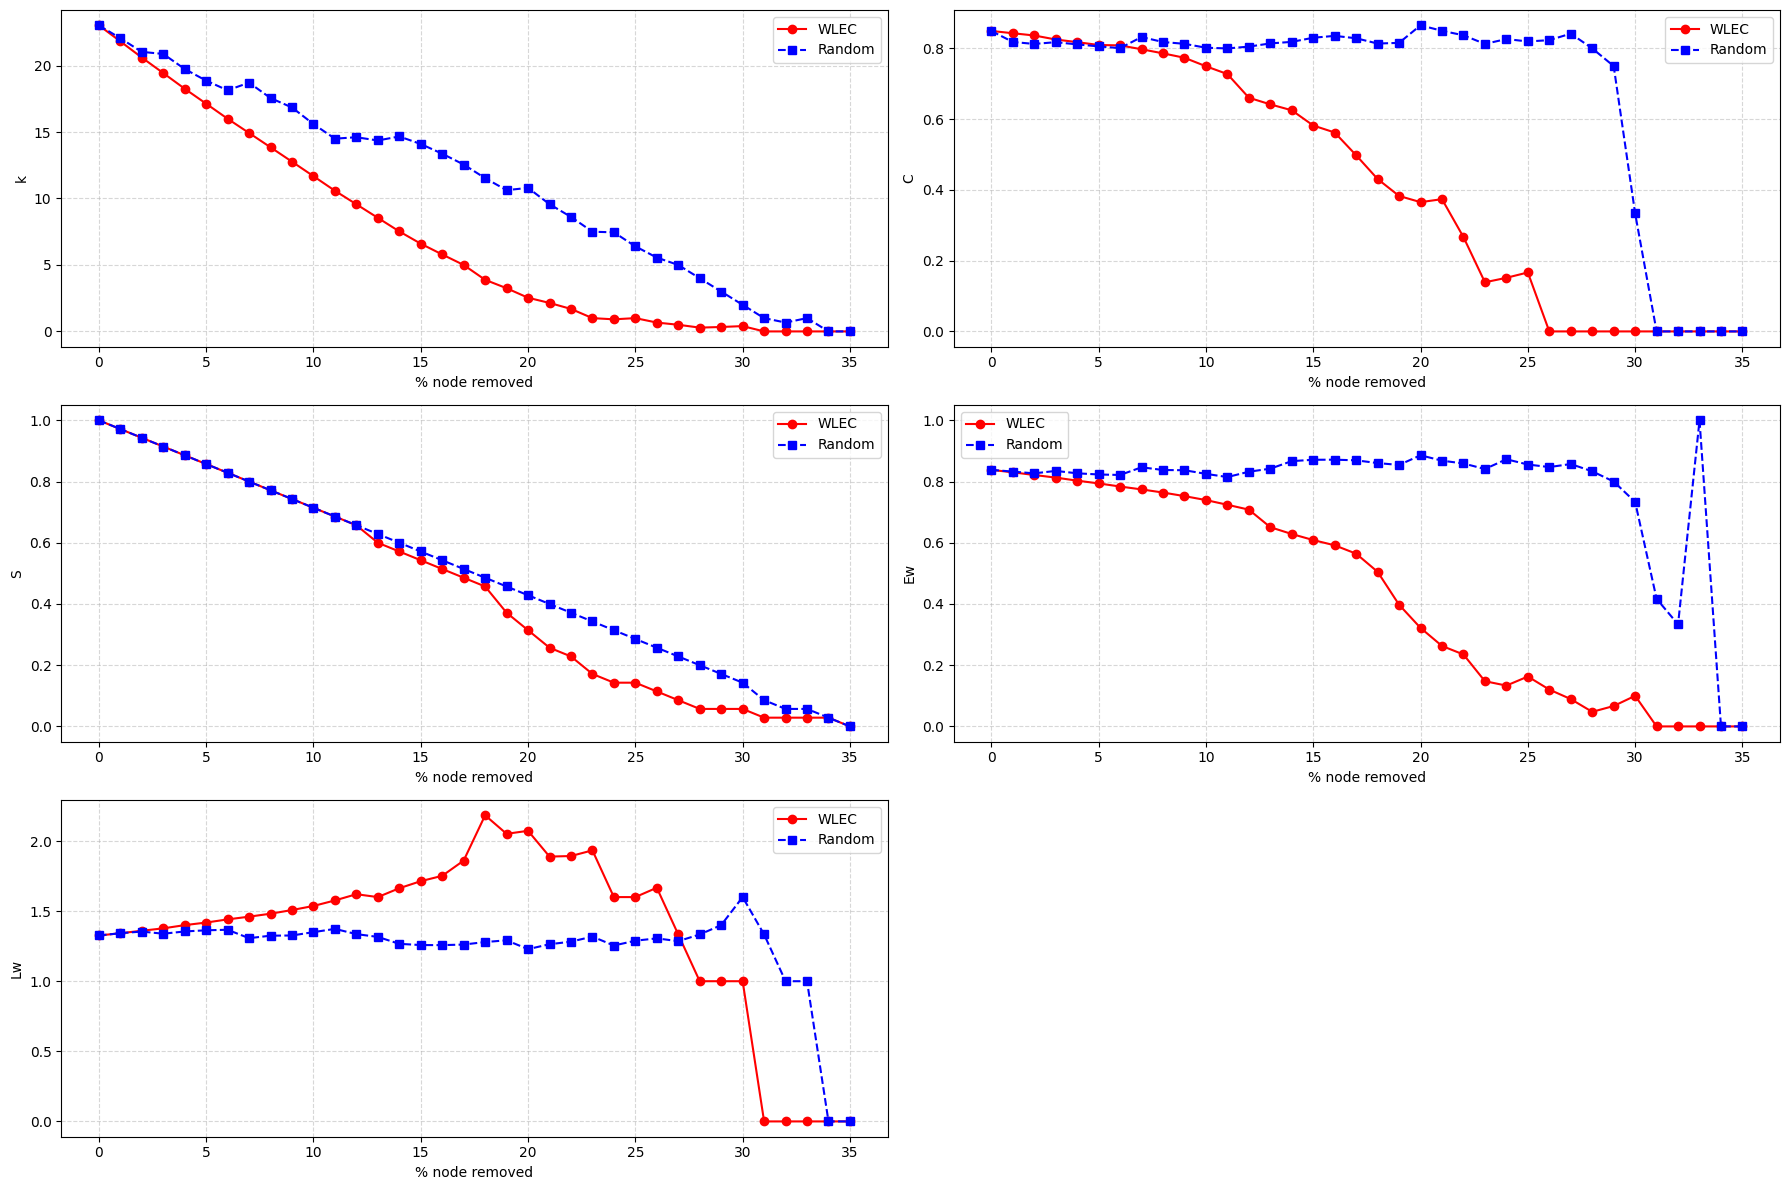

In [ ]:
import matplotlib.pyplot as plt

metrics = ["<k>", "C", "S", "Ew", "Lw"]
labels = ["k", "C", "S", "Ew", "Lw"]

plt.figure(figsize=(18, 12))

for i, metric in enumerate(metrics, 1):
    plt.subplot(3, 2, i)

    # Data WLEC
    plt.plot(
        df_seq_a[metric], marker='o', linestyle='-',
        color='red', label='WLEC'
    )

    # Data Random
    plt.plot(
        df_random[metric], marker='s', linestyle='--',
        color='blue', label='Random'
    )

    plt.xlabel("% node removed")
    plt.ylabel(labels[i-1])

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

plt.tight_layout()
plt.show()


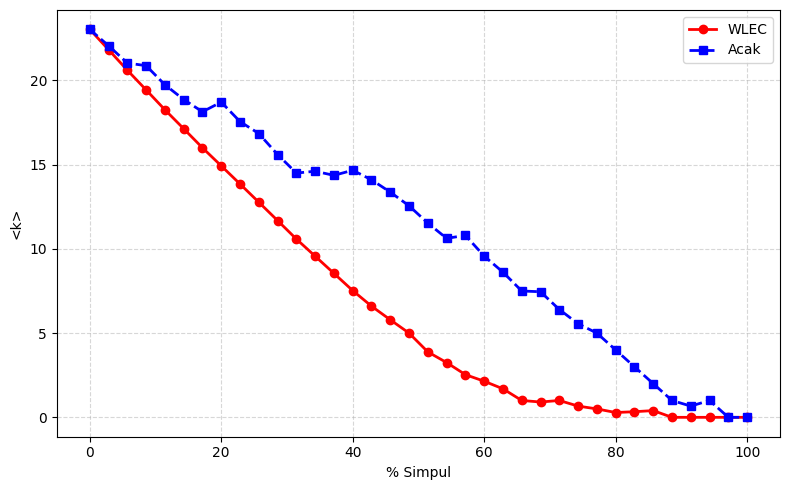

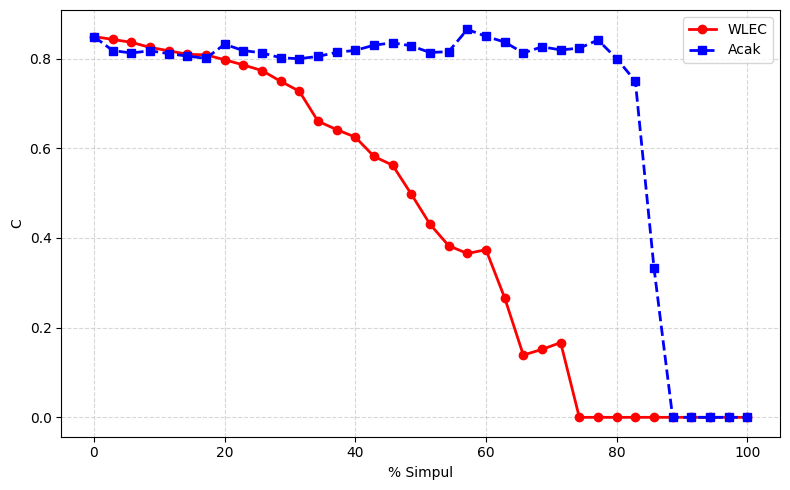

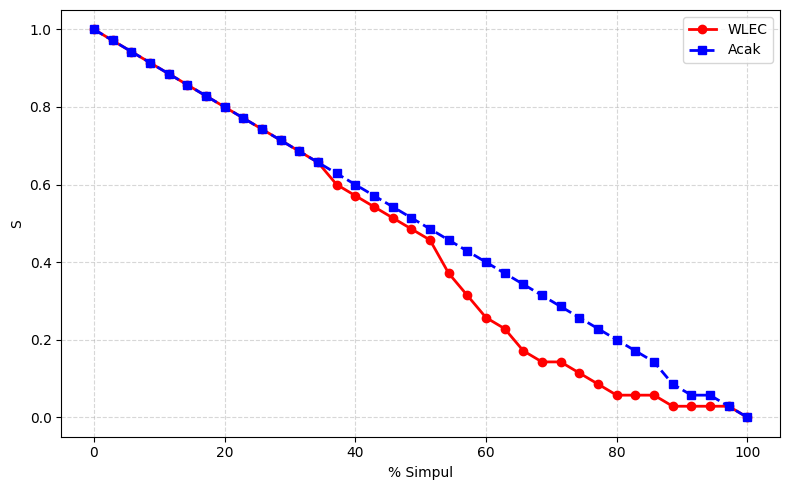

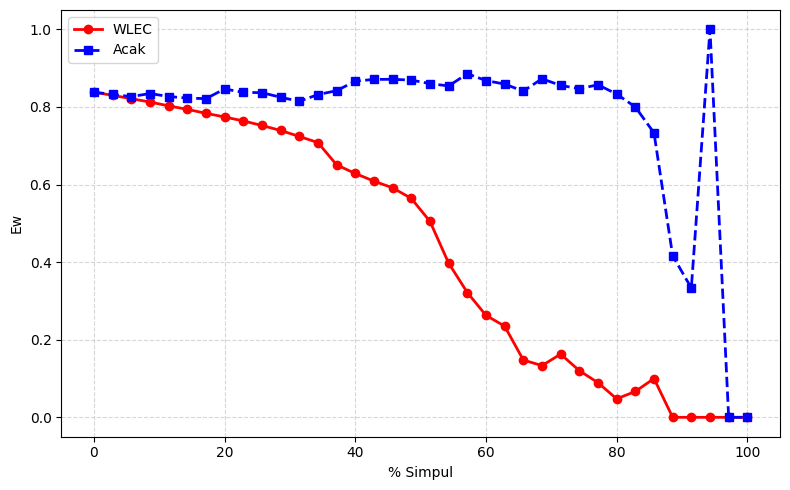

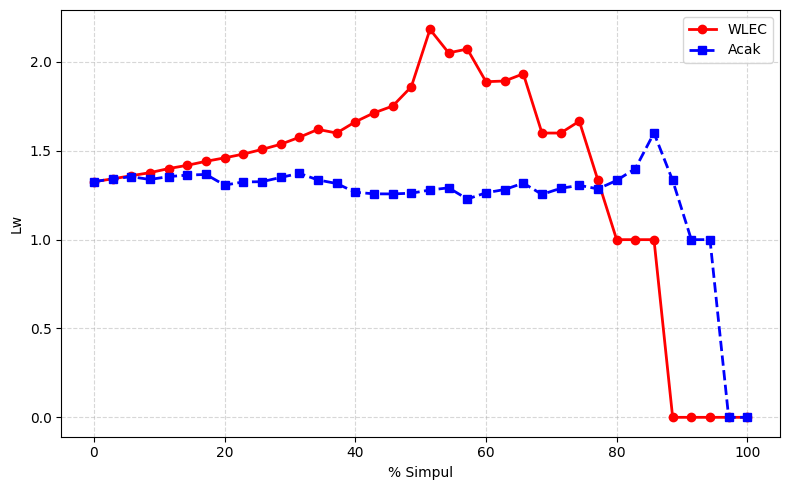

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["<k>", "C", "S", "Ew", "Lw"]
labels = ["<k>", "C", "S", "Ew", "Lw"]

# Total simpul awal (WAJIB dari graph awal)
N = len(df_seq_a) - 1
# asumsi baris ke-0 = 0% removal

# Sumbu X dalam persen
x_percent = np.linspace(0, 100, len(df_seq_a))

for i, metric in enumerate(metrics):
    plt.figure(figsize=(8, 5))

    # WLEC (MERAH)
    plt.plot(
        x_percent,
        df_seq_a[metric],
        marker='o',
        linestyle='-',
        color='red',
        linewidth=2,
        label='WLEC'
    )

    # RANDOM (BIRU)
    plt.plot(
        x_percent,
        df_random[metric],
        marker='s',
        linestyle='--',
        color='blue',
        linewidth=2,
        label='Acak'
    )

    plt.xlabel("% Simpul")
    plt.ylabel(labels[i])

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()


---------------------

**Perhatikan bagian S** : mula step 26 berarti komponen nya sudah mulai terpecah masing masing atauu jadi singgle node makanya nilanya jad 1/34 karena ya komoponennya sudah jadi beberapa komponnen / jadi node yang mandirii

* k = 0 → Semua node yang
tersisa tidak memiliki koneksi (degree = 0).

* C = 0 → Tidak ada lagi klaster lokal, karena tidak ada tetangga yang bisa membentuk klaster.
* S ≈ 0.029 → Ukuran largest component sangat kecil (hanya beberapa node tersisa yang terisolasi).

* Ew = 0 → Efisiensi global = 0 → jaringan tidak mampu lagi menyebarkan “pergerakan” antar node.

* Lw = 0 → Jarak rata-rata terpendek = 0 → karena tidak ada jalur yang tersisa.

#### Interpretasi antara dari urutan tertinggi dan dari urutan terendah

Pada penghapusan node dengan metode sequential removal dari node dengan centrality tertinggi ke terendah, jaringan mulai runtuh total sejak Step 26, ditandai dengan nilai <k>, C, Ew, dan Lw mendekati nol, menandakan sebagian besar node sudah terisolasi. Sebaliknya, jika penghapusan dilakukan dari node dengan centrality terendah ke tertinggi, jaringan tetap relatif stabil hingga tahap akhir. Nilai metrik menurun secara bertahap, tidak terjadi keruntuhan mendadak seperti pada penghapusan node terpenting atau bandara yang bersifat central. Begitupun ketika urutan hasil wlec dibandngkan dengan random removal, hasilnya sama, keruntuha  terjad secara bertahap.

### WLEC VS WLEC

In [ ]:
# ============================
#  WLEC B
# ============================

# 1. Daftar node urut berdasarkan WLEC B (LC3(v) tertinggi -> terendah)
wlec_b = [
    "CGK", "DPS", "KNO", "UPG", "BPN", "SUB", "PKU", "YIA", "PLM", "BTH",
    "PDG", "LOP", "PNK", "BDJ", "MDC", "AMQ", "SOQ", "TKG", "SRG", "SOC",
    "DJJ", "BTJ", "PLW", "KOE", "AAP", "LBJ", "TJQ", "TRK", "BIK", "MKQ",
    "HLP", "TNJ", "BWX", "KJT"
]

# 2. Sequential removal seperti WLEC-A
results_b = []
G_b = G.copy()
step = 0

baseline_b = {
    "<k>": average_degree(G),
    "C": average_clustering(G),
    "S": largest_connected_component_ratio(G),
    "Ew": weighted_efficiency(G),
    "Lw": average_weighted_path_length(G),
}

results_b.append({
    "Step": step,
    "Removed": "NONE",
    **baseline_b
})

for node in wlec_b:
    step += 1
    if node in G_b:
        G_b.remove_node(node)
    metrics = {
        "<k>": average_degree(G_b),
        "C": average_clustering(G_b),
        "S": largest_connected_component_ratio(G_b),
        "Ew": weighted_efficiency(G_b),
        "Lw": average_weighted_path_length(G_b),
    }
    results_b.append({
        "Step": step,
        "Removed": node,
        **metrics
    })

df_seq_b = pd.DataFrame(results_b)
print(df_seq_b)


    Step Removed        <k>         C         S        Ew        Lw
0      0    NONE  23.028571  0.849286  1.000000  0.838095  1.326050
1      1     CGK  21.823529  0.842834  0.971429  0.830065  1.342246
2      2     DPS  20.666667  0.832928  0.942857  0.822285  1.357955
3      3     KNO  19.500000  0.826107  0.914286  0.813844  1.375000
4      4     UPG  18.451613  0.819689  0.885714  0.806810  1.389247
5      5     BPN  17.200000  0.810298  0.857143  0.795019  1.416092
6      6     SUB  16.068966  0.809083  0.828571  0.784893  1.438424
7      7     PKU  15.000000  0.800157  0.800000  0.775132  1.460317
8      8     YIA  14.000000  0.806623  0.771429  0.766382  1.478632
9      9     PLM  12.923077  0.790013  0.742857  0.754872  1.504615
10    10     BTH  11.760000  0.779150  0.714286  0.740000  1.540000
11    11     PDG  10.750000  0.728899  0.685714  0.724638  1.586957
12    12     LOP   9.652174  0.707361  0.657143  0.708169  1.628458
13    13     PNK   8.818182  0.644717  0.628571 

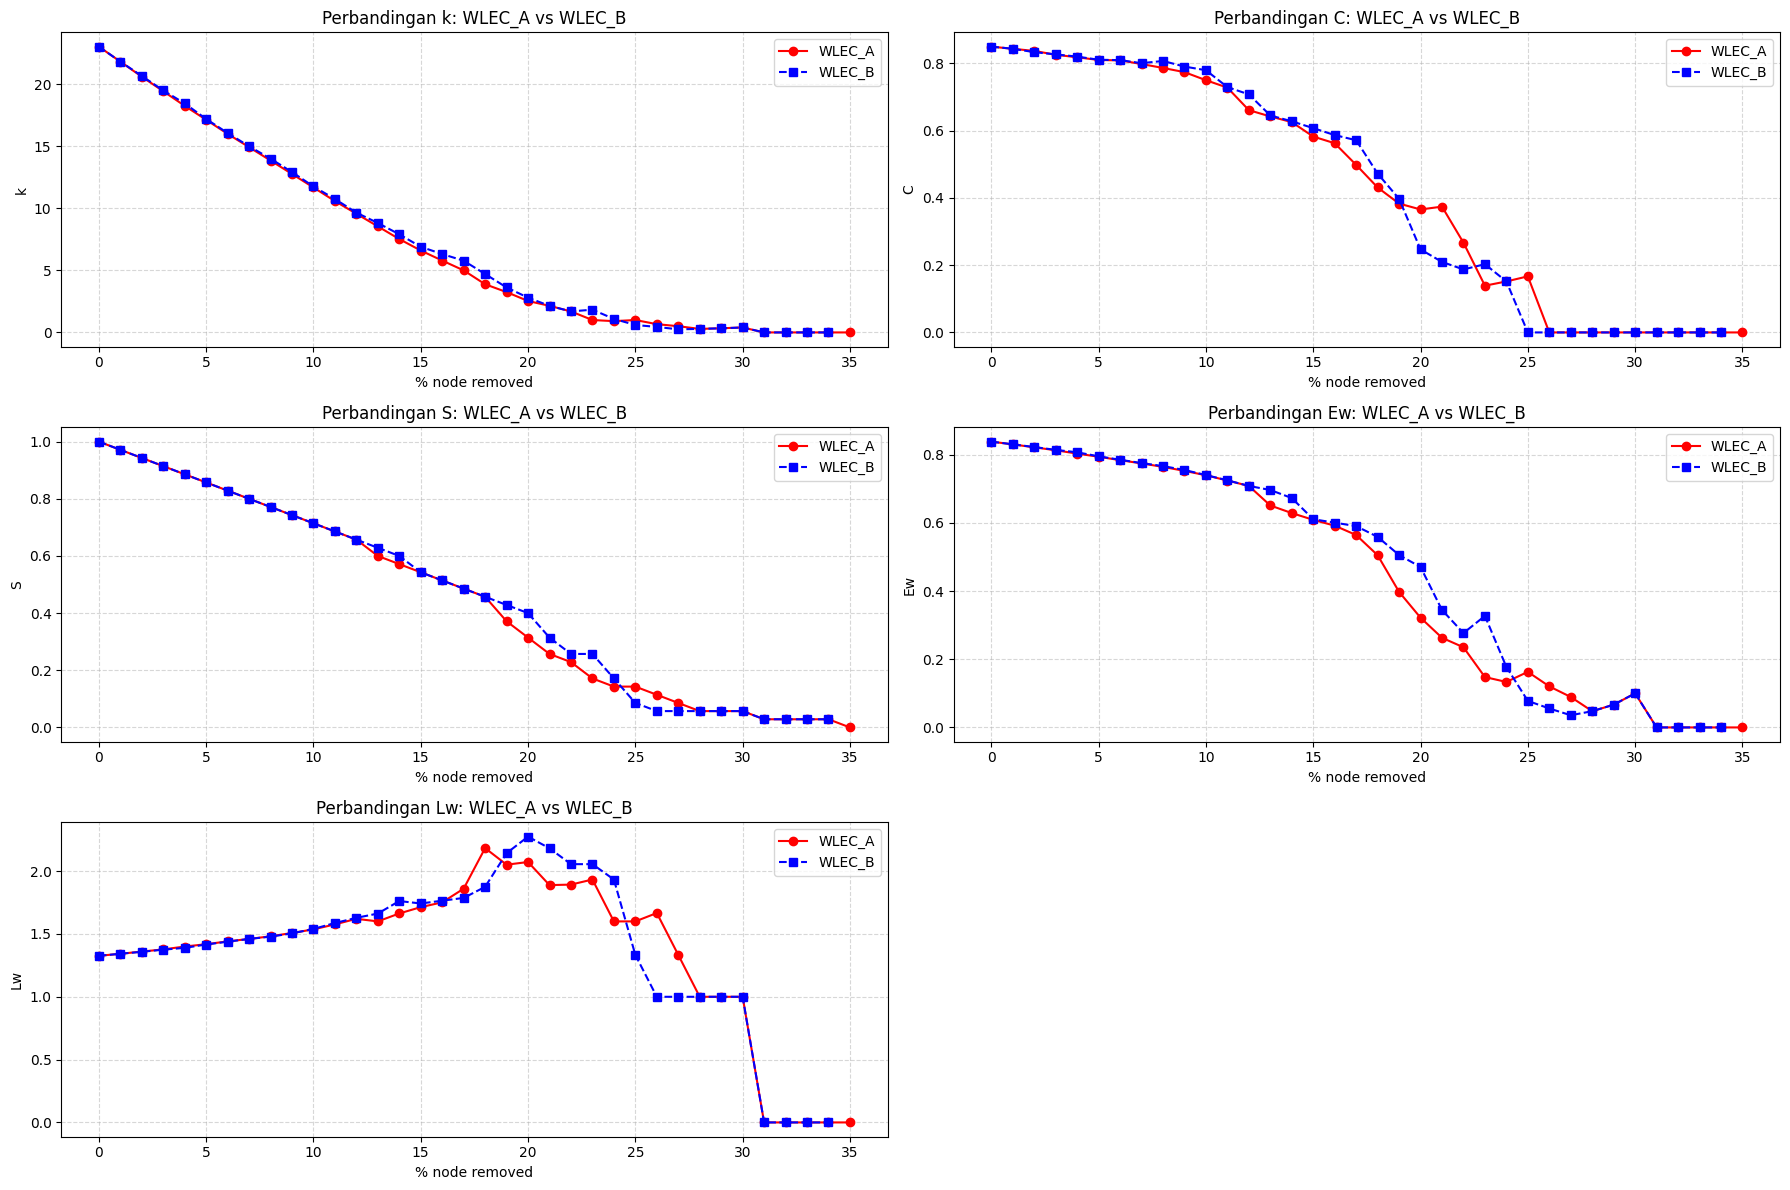

In [ ]:
import matplotlib.pyplot as plt

metrics = ["<k>", "C", "S", "Ew", "Lw"]
labels = ["k", "C", "S", "Ew", "Lw"]

plt.figure(figsize=(18, 12))

for i, metric in enumerate(metrics, 1):
    plt.subplot(3, 2, i)

    # Data WLEC_A
    plt.plot(
        df_seq_a[metric], marker='o', linestyle='-',
        color='red', label='WLEC_A'
    )

    # Data WLEC_B
    plt.plot(
        df_seq_b[metric], marker='s', linestyle='--',
        color='blue', label='WLEC_B'
    )

    plt.xlabel("% node removed")
    plt.ylabel(labels[i-1])
    plt.title(f"Perbandingan {labels[i-1]}: WLEC_A vs WLEC_B")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

plt.tight_layout()
plt.show()


NameError: name 'H' is not defined

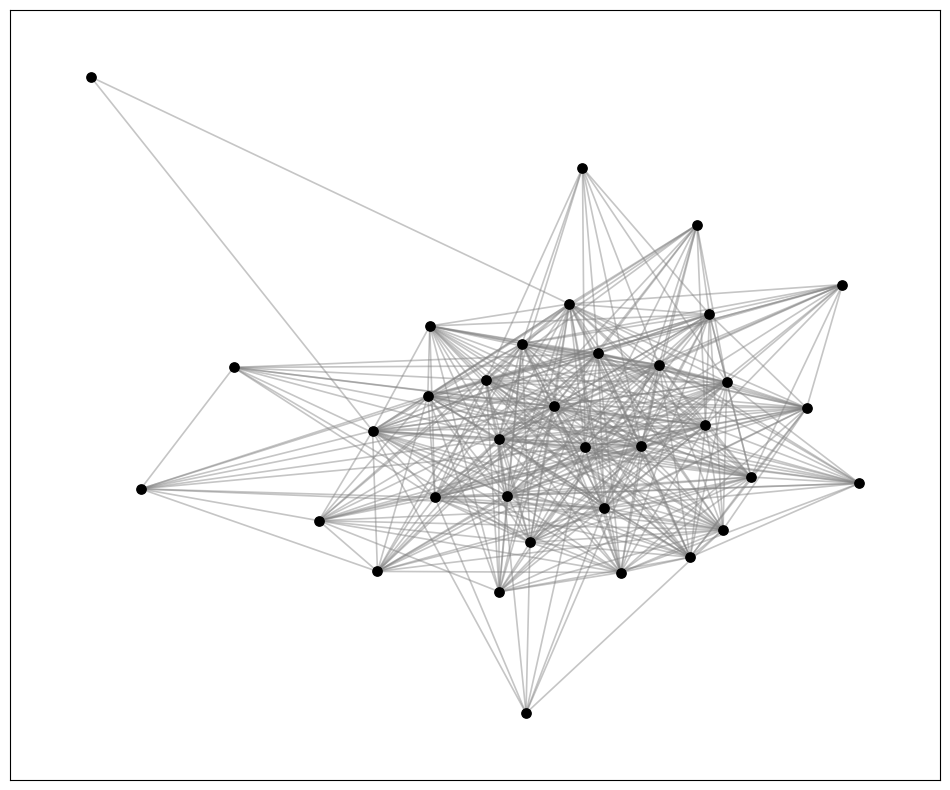

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

# Layout
pos = nx.spring_layout(G, seed=42)

# ---- Garis abu-abu diperjelas (lebih tebal) ----
nx.draw_networkx_edges(
    G, pos,
    alpha=0.45,
    width=1.2,        # <= perbesar ketebalan garis abu
    edge_color="gray"
)

# ---- Node utama ----
nx.draw_networkx_nodes(G, pos, node_size=45, node_color="black")

# ---- Subgraf / komponen merah ----
nx.draw_networkx_edges(H, pos, edge_color="red", width=2.8)
nx.draw_networkx_nodes(H, pos, node_size=70, node_color="red")

# ---- Label dengan offset agar tidak tertutup node ----
label_pos = {}
offset_x = 0.025
offset_y = 0.025

for node, (x, y) in pos.items():
    label_pos[node] = (x + offset_x, y + offset_y)

nx.draw_networkx_labels(
    G,
    label_pos,
    font_size=7,
    font_color="black"
)

plt.axis("off")
plt.tight_layout()
plt.show()


## keanehan


matriks S : tetapi harusnya kalo yang dihapus CGK dlu akan beda gasi kondisinya ketika kjt yang dhapus duluan?

Praktiknya: di jaringan dense / redundant, penghapusan satu node kecil atau satu node besar di awal tidak langsung memecah giant component → S awal terlihat sama.

Dia hanya menghitung ukuran komponen terbesar saat ini, dibagi jumlah node awal.

Tidak peduli node yang dihapus itu penting atau tidak, atau berapa banyak tetangga yang masih saling terhubung, atau degree / clustering node itu.

Yang dihitung hanyalah: “berapa node yang masih berada di subgraf terbesar?”

Jadi memang, metrik S ini tidak sensitif terhadap karakteristik node individual.

**TAPI NODE 1 DAN KETIKA DIBALIK JADI NODE 5 , IMPACT NYA AKAN SAMA TU TERGANTUNG SIAPA DLU YANG DIHAPUS AJA, BRRTI ENGGA MENGGAMBARKAN URUTAN HASIL WLEC YANG ASLI**



Sequential removal menghitung dampak kumulatif: setiap node yang dihapus berikutnya sudah “mengalami kerusakan” akibat node-node sebelumnya yang dihapus.

Jadi, impact per node dalam sequential bukan lagi murni dampak node itu sendiri, tapi dampak tambahan node itu setelah jaringan melemah.

Akibatnya, kalau kamu membalik urutan WLEC, node yang tadinya paling penting (misal CGK) jadi dihapus terakhir, impact per step-nya jadi lebih besar daripada ketika dihapus pertama — padahal “kritisitas” aslinya tetap sama.

Kesimpulan:

Sequential removal tidak mencerminkan urutan ranking WLEC secara murni.

Kalau kamu ingin mengukur seberapa penting node menurut WLEC asli, lebih tepat pakai single node removal, karena di sana setiap node diuji satu-satu tanpa dipengaruhi penghapusan node lain.

Sequential bagus untuk mensimulasikan kerusakan bertahap jaringan, tapi bukan untuk validasi ranking WLEC.